# 03 — Filing dates

Reads `reference/filing_dates.csv` and `reference/filers.csv` with their provenance records, and asks whether the table is fit to compute observation status from.

The filing date is what the evidence maturity date is built on. A claim is observable only once the filings covering its window have been published, so an error here does not degrade a result, it moves claims between OBSERVABLE and RIGHT_CENSORED.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT / "src"))

pd.set_option("display.max_colwidth", 60)
pd.set_option("display.width", 200)

REF = PROJECT_ROOT / "reference"
# keep_default_na: the suspect column is empty for good rows, and pandas would
# read those as NaN, which silently breaks every == "" comparison below.
filings = pd.read_csv(
    REF / "filing_dates.csv",
    parse_dates=["fiscal_period", "filed_date"],
    keep_default_na=False,
)
filings["lag_days"] = filings["lag_days"].astype(int)
filers = pd.read_csv(REF / "filers.csv")
prov = json.loads((REF / "filing_dates.provenance.json").read_text())
filer_prov = json.loads((REF / "filers.provenance.json").read_text())

names = {int(k): v["name"] for k, v in prov["filers"].items() if k != "_failures"}
filings["name"] = filings["cik"].map(names)

print(f"{len(filings):,} rows, {filings['cik'].nunique()} filers, built at commit {prov['commit']}")
print(f"window {prov['study_window'][0]}-{prov['study_window'][1]}, forms {', '.join(prov['forms'])}")

7,118 rows, 148 filers, built at commit 8b474ee
window 2012-2024, forms 10-K, 10-Q


## Who is in the study

The filers this table covers, and the limitations the selection records against itself. `02_filers.ipynb` works through what the rule admits and where it fails; what matters here is that the set is fixed before filing dates are pulled, so a change upstream invalidates this table rather than degrading it.

In [2]:
for line in filer_prov["limitations"]:
    print(f"- {line}")
print()
print(f"revenue range: {filers['revenue'].min()/1e9:,.1f}B to {filers['revenue'].max()/1e9:,.0f}B")
filers.head(8)[["rank", "name", "location", "revenue"]]

- Ranking at one recent year is a survivorship filter: filers large in 2012 that have since shrunk or delisted cannot appear.
- Revenue is a size proxy, not market capitalisation, and over-weights low-margin distribution: three drug wholesalers outrank Microsoft.
- Whether a financial firm appears is decided by tagging practice rather than size. Goldman Sachs, Morgan Stanley, Wells Fargo and Truist tag neither revenue element, so no cutoff admits them.
- The per-CIK dedupe cannot see one business filing under two CIKs, so several corporate families hold more than one slot.
- The definitive study set is this list intersected with the transcript corpus.

revenue range: 25.5B to 648B


,rank,name,location,revenue
0,1,Walmart Inc.,US-AR,648125000000
1,2,"AMAZON.COM, INC.",US-WA,574785000000
2,3,Apple Inc.,US-CA,383285000000
3,4,UnitedHealth Group Incorporated,US-MN,371622000000
4,5,BERKSHIRE HATHAWAY INC,US-NE,364482000000
5,6,CVS HEALTH CORPORATION,US-RI,357776000000
6,7,Exxon Mobil Corporation,US-TX,344582000000
7,8,McKESSON CORPORATION,US-TX,308951000000


## Filing lag

The gap between period end and filing date is what makes the evidence maturity date non-trivial: a window can close weeks before the report covering it exists.

The distribution also exposes bad data. A periodic report cannot be filed before its period ends, and in practice not within a fortnight of it, so anything shorter means EDGAR's `reportDate` is wrong rather than the filer was fast.

In [3]:
lag = filings.groupby("form_type")["lag_days"].describe()[["count", "min", "25%", "50%", "75%", "max"]]
lag.columns = ["rows", "min", "p25", "median", "p75", "max"]
lag.astype(int)

,rows,min,p25,median,p75,max
form_type,,,,,,
10-K,1788,0,43,50,56,107
10-Q,5330,0,27,32,36,392


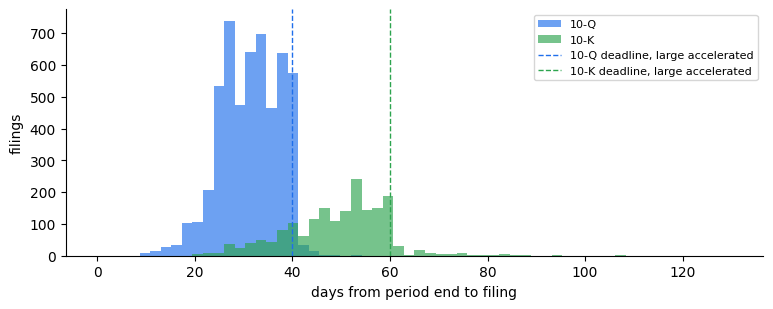

In [4]:
# Where the statutory deadlines actually sit, against the observed median.
# Constructed for reading only; committed figures come from the figure script.
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.2))
for form, colour in (("10-Q", "#1f6feb"), ("10-K", "#2da44e")):
    subset = filings[(filings["form_type"] == form) & (filings["suspect"] == "")]
    ax.hist(subset["lag_days"], bins=60, range=(0, 130), alpha=0.65, label=form, color=colour)
ax.axvline(40, ls="--", c="#1f6feb", lw=1, label="10-Q deadline, large accelerated")
ax.axvline(60, ls="--", c="#2da44e", lw=1, label="10-K deadline, large accelerated")
ax.set_xlabel("days from period end to filing")
ax.set_ylabel("filings")
ax.legend(fontsize=8)
ax.spines[["top", "right"]].set_visible(False)
plt.show()

Both forms cluster just inside their statutory deadline, which is what you would expect and is a sanity check on the pull.

The practical consequence for adjudication: a claim whose window closes on 31 December is not answerable until early February for a 10-Q and into March for a 10-K. Using period end instead of filing date would mark those claims observable weeks before the evidence existed.

## Rows the table does not trust

EDGAR's `reportDate` is wrong for a small share of filings, and `fiscal_period` is the key adjudication joins on, so a wrong period matches a claim to the wrong filing or to none.

These are flagged rather than dropped. A short lag is almost certainly a bad date; a long one may be genuine delinquency, which the study treats as its own case.

The short threshold is set from the data rather than assumed. Lags of 0 to 3 days are impossible, since no accounting close happens in three days. Nothing then appears until 9 days, after which Delta and Oracle form a coherent cluster at 10 to 14 across dozens of filings: those two genuinely file fast. An earlier threshold of 15 days flagged 40 of their legitimate filings as errors, which is the failure mode a fixed guess invites.

In [5]:
suspect = filings[filings["suspect"] != ""]
print(f"{len(suspect)} of {len(filings):,} rows flagged ({100*len(suspect)/len(filings):.1f}%)")
print(suspect["suspect"].value_counts().to_string())
print()
cols = ["name", "form_type", "fiscal_period", "filed_date", "lag_days", "suspect"]
suspect.sort_values("lag_days")[cols].head(6).reset_index(drop=True)

10 of 7,118 rows flagged (0.1%)
suspect
lag_implausibly_short    6
lag_long                 4



,name,form_type,fiscal_period,filed_date,lag_days,suspect
0,EXXON MOBIL CORP,10-Q,2012-11-06,2012-11-06,0,lag_implausibly_short
1,GENERAL ELECTRIC CO,10-Q,2014-07-31,2014-07-31,0,lag_implausibly_short
2,GENERAL ELECTRIC CO,10-K,2015-02-27,2015-02-27,0,lag_implausibly_short
3,INTERNATIONAL BUSINESS MACHINES CORP,10-Q,2014-04-29,2014-04-29,0,lag_implausibly_short
4,GENERAL ELECTRIC CO,10-Q,2014-11-03,2014-11-04,1,lag_implausibly_short
5,GENERAL ELECTRIC CO,10-Q,2014-05-09,2014-05-12,3,lag_implausibly_short


Exxon's Q3 2012 10-Q is the clearest case: `reportDate` duplicates the filing date, giving a zero-day lag. The document is `xom10q3q12.htm`, so the period ended 30 September. Its Q1 and Q2 neighbours carry the correct dates, so this is a per-row defect rather than a filer-level one.

Flex is the other failure mode: a period of 2012-10-27 filed a year later, sitting alongside the correct 2012-09-28 filed on time. Flex has a March year end, so October is not a quarter end for them at all.

## Window coverage

A filer missing years cannot contribute claims from them. This reduces the sample rather than producing a wrong answer, but it needs to be visible before the corpus is sampled.

In [6]:
entries = [v for k, v in prov["filers"].items() if k != "_failures"]
coverage = pd.DataFrame([
    {"name": e["name"], "filings": e["filings_in_window"],
     "years": len(e["years_covered"]), "complete": e["complete"]}
    for e in entries
])

print(f"complete across 2012-2024: {coverage['complete'].sum()} of {len(coverage)} filers")
print(f"zero filings in window:     {(coverage['filings'] == 0).sum()}")
coverage.sort_values("filings").head(12).reset_index(drop=True)

complete across 2012-2024: 119 of 150 filers
zero filings in window:     2


,name,filings,years,complete
0,Galaxy Digital Inc.,0,0,False
1,Paramount Skydance Corp,0,0,False
2,Ingram Micro Holding Corp,2,1,False
3,Ferguson Enterprises Inc. /DE/,2,1,False
4,GE Vernova Inc.,4,1,False
5,"Apollo Global Management, Inc.",12,3,False
6,HF Sinclair Corp,12,3,False
7,DOW INC.,24,6,False
8,"Uber Technologies, Inc",24,6,False
9,Walt Disney Co,24,6,False


## What this means for the pilot

**The table is usable, with 10 rows to treat carefully.** 7,118 rows across 148 filers that have any, no fetch failures, and the flagged rows are 0.1 per cent. The `suspect` column carries them forward rather than hiding them, so the observation-status calculator in issue 7 can decide whether to exclude or repair.

**Filing lag is the reason this table exists.** The median 10-Q arrives 32 days after its period ends, the median 10-K 50 days. Computing observability from period end rather than filing date would mark claims answerable weeks before the evidence was published, which is precisely the circularity the manual's evidence maturity date was written to avoid.

**Coverage is not uniform.** 119 of 150 filers span the full window; two have no filings in it at all. The pilot samples passages, not filers, so an unevenly covered filer contributes fewer claims rather than biasing the ones it does contribute, but the two empty filers should be dropped before sampling.

**The selection is survivorship-filtered**, and no amount of care in this table fixes that. It is a property of ranking by present-day revenue, and it bounds what the study can claim about management reliability.